
## Image Modelling Part 1 - Preprocessing
In this notebook we will cover two interesting topics: how to prepare images for training a neural network and using shell commands instead of pandas to do so.
We will work with the flower dataset, which consists of pictures of different flowers and their respective specie as class label. We’ll start by preparing the data in a way that it can be loaded into tensorflow, followed by the loading itself and checking if everything went fine. Each step will be defined as a function, which we will directly write into a python file. In the second notebook we will import and use those functions in order to train a neural network that classifies our flower pictures.
### Objective
At the end of the notebook, you should...
* know how to automatically write code from your notebook to a python file.
* be familiar with some shell commands to prepare your data.
* how to prepare and load your image data into tensorflow.

In [35]:
# Remove any file that gets constructed by the notebook.
!rm -f image_modeling.py flowers_train.csv flowers_eval.csv flowers_test.csv

The following cell defines a register cell magic which lets you write the content of a cell into a python script automatically, while still executing the cell. Mode 'a' (can be set with the -a flag) appends to the file while mode 'w' overwrites all existing lines.

In [36]:
!python -c "import numpy; print(numpy. __version__)"
!python -c "import tensorflow; print(tensorflow.__version__)" 

1.26.4
2.16.2


In [37]:
import numpy as np
print(np.__version__)

1.26.4


In [57]:
# Let's make some dark cell magic. Why not!
from IPython.core.magic import register_cell_magic

@register_cell_magic
def write_and_run(line, cell):
    argz = line.split()
    file = argz[-1]
    mode = 'w'
    if len(argz) == 2 and argz[0] == '-a':
        mode = 'a'
        print("Appended to file ", file)
    else:
        print('Written to file:', file)
    with open(file, mode) as f:
        f.write(cell.format(**globals()))        
    get_ipython().run_cell(cell)

Import needed libraries. `%%write_and_run image_modeling.py` is the call of the register cell magic from above in 'w' mode (default). It writes the imports at the beginning of the `image_modeling.py`.

In [58]:
%%write_and_run image_modeling.py
import pathlib
import IPython.display as display
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow
import tensorflow as tf

Written to file: image_modeling.py


Print the tensorflow version and set the threshold for what messages will be logged. 

In [59]:
print(tf.__version__)
tf.compat.v1.logging.set_verbosity(v=tf.compat.v1.logging.INFO)

2.16.2


Here you download the data. The images will be stored in `~/.keras/datasets/flower_photos` in the respective folders for each class of flowers (roses, sunflowers, daisy, dandelion, tulips). 

In [41]:
#Execute the following cell to download the data. 
#Then comment out the cell to avoid re-downloading the data.
# data_dir = tf.keras.utils.get_file(
#     'flower_photos',
#     'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz',
#     untar=True
# )

# print('cd', data_dir)

Get the absolute path to the data folder, count all images and get the class names. 

In [60]:
# Get paths as POSIX paths
home_path = str(pathlib.Path.home())
data_dir = home_path + '/.keras/datasets/flower_photos'
data_dir = pathlib.Path(data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print("We have", image_count, "images.")

# Get classes
CLASS_NAMES = np.array(
    [item.name for item in data_dir.glob('*') if item.name != "LICENSE.txt"]
)
print("We have the following classes in the data: ", CLASS_NAMES)

We have 0 images.
We have the following classes in the data:  []


Let's look at some roses...

In [61]:
# Get all roses images
roses = list(data_dir.glob('roses/*'))

for image in roses[:3]:
    display.display(Image.open(str(image)))

## Data preparation using shell commands

Now we will use shell commands to look at the data, clean the paths to the images and split our data into train and evaluation set.

`flowers_train_generic.csv` contains the paths to the images and their respective classes. Let's look at the first five entries. First we use the [head](https://linuxhint.com/bash_head_tail_command/) command to generate the first five lines of the `flowers_train_generic.csv`. Then we redirect the output of the [head](https://linuxhint.com/bash_head_tail_command/) command to the `/tmp/input.csv` via the ['>'](https://www.cs.ait.ac.th/~on/O/oreilly/unix/upt/ch13_01.htm#UPT-ART-1023) operator. We now print the content of this file with the [cat](https://www.interserver.net/tips/kb/linux-cat-command-usage-examples/?__cf_chl_f_tk=sbsfrwcq2e.iPk93oGmvT0LSXdGVW7BuzsZsRhl85GI-1642513145-0-gaNycGzNCOU) command.

In [62]:
# Let us take a look into the training set
!head -5 flowers_train_generic.csv > /tmp/input.csv 
!cat /tmp/input.csv

~/.keras/datasets/flower_photos/daisy/754296579_30a9ae018c_n.jpg,daisy
~/.keras/datasets/flower_photos/dandelion/18089878729_907ed2c7cd_m.jpg,dandelion
~/.keras/datasets/flower_photos/dandelion/284497199_93a01f48f6.jpg,dandelion
~/.keras/datasets/flower_photos/dandelion/3554992110_81d8c9b0bd_m.jpg,dandelion
~/.keras/datasets/flower_photos/daisy/4065883015_4bb6010cb7_n.jpg,daisy


We see that the paths contain '~', which refers to the home directory. Unfortunately the Tensorflow Dataset API cannot handle it. So we write new files containing the user path instead of '~', named flowers_train.csv and flowers_test.csv. 

So how are the following commands doing this?

- first we generate standard output with the content of flowers_train_generic.csv with the cat command.
- the [pipe operator](https://www.cs.ait.ac.th/~on/O/oreilly/unix/upt/ch13_01.htm#UPT-ART-1023) '|' uses the output of whats left of it as the input for whats right of it.
- so we use the output of cat as input of the [sed](https://www.geeksforgeeks.org/sed-command-in-linux-unix-with-examples/?ref=lbp) command. Note: here the delimiter is '+'
- the 's' in `s+~+{home_path}+g` specifies the substitution operation and 'g' stands for globally so all occurrences will be replaced.
- finally sed `s+~+{home_path}+g` replaces all '~' with the home_path variable and the output is written to a new file via '>'
- `home_path` is the variable we defined above.

In [63]:
# TensorFlow Dataset API cannot work with the '~' character,
# so we replace it with the user path.
!cat flowers_train_generic.csv | sed 's+~+{home_path}+g' > flowers_train.csv
!cat flowers_test_generic.csv | sed 's+~+{home_path}+g' > flowers_test.csv
!head -5 flowers_train.csv

/Users/bimladanu/.keras/datasets/flower_photos/daisy/754296579_30a9ae018c_n.jpg,daisy
/Users/bimladanu/.keras/datasets/flower_photos/dandelion/18089878729_907ed2c7cd_m.jpg,dandelion
/Users/bimladanu/.keras/datasets/flower_photos/dandelion/284497199_93a01f48f6.jpg,dandelion
/Users/bimladanu/.keras/datasets/flower_photos/dandelion/3554992110_81d8c9b0bd_m.jpg,dandelion
/Users/bimladanu/.keras/datasets/flower_photos/daisy/4065883015_4bb6010cb7_n.jpg,daisy


Now the paths in `flowers_train.csv` and `flowers_test.csv` are in the path format needed for Tensorflow.

In order to be able to see if our model is overfitting we need to split our train set again into a train set and an evaluation set. To make results comparable we want to randomly split with a seed specified by the file random.seed. 

- first we use the `sort -R` command to shuffle our the lines in flowers_train.csv. `--random-source=random.seed` sets the random seed.
- then we use this output as input for the [split -l](https://www.geeksforgeeks.org/split-command-in-linux-with-examples/) command via pipe ('|').
- `split -l` then takes the pseudo randomized data and splits it into two files after a specified number of lines. 
- the [wc -l](https://www.geeksforgeeks.org/wc-command-linux-examples/) counts the number of lines in a file.
- So finally we get a train file with 2930 and a evaluation file with 370 lines.

>__Exercise__: use the `wc -l` command to check the length of the two files in your terminal

Note that due to the `%%bash` in the beginning of the cell we can omit the usual '!' in front of the shell command. 

In [64]:
%%bash
# Let us also create an evaluation set from the train set.
# We want to have a fixed seed.
# NOTE: 'sort -R' is used to shuffle the data. If there are
# duplicates it sorts them next to each others, which we 
# want to have, since we want to avoid evaluation leakage.
sort -R flowers_train.csv --random-source=random.seed | split -l $(( $(wc -l <flowers_train.csv) - 370)) - flowers_train
mv flowers_trainaa flowers_train.csv
mv flowers_trainab flowers_eval.csv

Next we want to extract the labels from the `flowers_train.csv`. You should be able to understand how it is done here with what you learned so far. Please write your own description of what step does. 

New commands here are:
- [awk](https://www.geeksforgeeks.org/awk-command-unixlinux-examples/) lets you, amongst other things, select fields separated by white spaces in a file.
- [uniq](https://linuxhint.com/bash_uniq_command/) removes adjacent duplicate lines from a file.

Why is the `sort` command used? Why are the ',' replaced with whitespaces?

In [65]:
# Extract the labels from the train data 
!cat flowers_train.csv | sed 's/,/ /g' | awk '{print $2}' | sort | uniq > /tmp/labels.txt
!cat /tmp/labels.txt

daisy
dandelion
roses
sunflowers
tulips


## Define functions to process the data

From now on we will use python and Tensorflow to define some variables and functions to be used in the second notebook when we train our CNN to classify images of flowers.

We set some parameters for the model and call the register cell magic `write_and_run` again this time with the `-a` flag. This makes sure that the content of the cell is appended to `image_modeling.py` and existing lines are not overwritten.

In [66]:
%%write_and_run -a image_modeling.py

# We set some parameters for the model
HEIGHT = 224 #image height
WIDTH = 224 #image width
CHANNELS = 3 #image RGB channels
CLASS_NAMES = ['daisy', 'tulips', 'roses', 'dandelion', 'sunflowers']
NCLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
SHUFFLE_BUFFER = 10 * BATCH_SIZE
AUTOTUNE = tf.data.experimental.AUTOTUNE

VALIDATION_SIZE = 370
VALIDATION_STEPS = VALIDATION_SIZE // BATCH_SIZE

Appended to file  image_modeling.py


We define a function which takes the jpeg image and returns the image in a format which can be used by Tensorflow. We also write it to the end of `image_modeling.py`.

In [67]:
%%write_and_run -a image_modeling.py

# Define the function that decodes in the images
def decode_image(image, reshape_dim):
    # JPEG is a compressed image format. So we want to 
    # convert this format to a numpy array we can compute with.
    image = tf.image.decode_jpeg(image, channels=CHANNELS)
    # 'decode_jpeg' returns a tensor of type uint8. We need for 
    # the model 32bit floats. Actually we want them to be in 
    # the [0,1] interval.
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Now we can resize to the desired size.
    image = tf.image.resize(image, reshape_dim)
    
    return image

Appended to file  image_modeling.py


Let us look at the result of the `decode_image` function. Call it here, see TODO below.

In [ ]:
import os

# Check base path
home_path = os.path.expanduser("~")
dataset_path = os.path.join(home_path, '.keras/datasets/flower_photos')
print(os.path.exists(dataset_path))          # True or False
print(os.listdir(dataset_path))      

In [73]:
import os
import pathlib
import tensorflow as tf

# ── 1. Download & auto-extract ────────────────────────────
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    origin=dataset_url,
    fname='flower_photos',
    untar=True                        # auto-extracts the .tgz
)

data_dir = pathlib.Path(data_dir)
print("Dataset location:", data_dir)  # confirms real path

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 55s 0us/step
Dataset location: /Users/bimladanu/.keras/datasets/flower_photos


In [78]:
img = tf.io.read_file('/Users/bimladanu/.keras/datasets/flower_photos/flower_photos/roses/99383371_37a5ac12a3_n.jpg')
decode_image(img, [HEIGHT, WIDTH])

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.28791142, 0.2761655 , 0.20164631],
        [0.30667895, 0.29749465, 0.21795532],
        [0.3347339 , 0.33081234, 0.2484594 ],
        ...,
        [0.7607406 , 0.7646622 , 0.7097602 ],
        [0.7592963 , 0.7632178 , 0.7083158 ],
        [0.7537284 , 0.7576499 , 0.7027479 ]],

       [[0.28387418, 0.2742591 , 0.1990684 ],
        [0.3025385 , 0.29896396, 0.22054197],
        [0.33474326, 0.3308217 , 0.24846879],
        ...,
        [0.75660956, 0.7605311 , 0.70536655],
        [0.75127804, 0.7551996 , 0.70003504],
        [0.7486538 , 0.75257546, 0.6974109 ]],

       [[0.27949056, 0.2838498 , 0.21304274],
        [0.2953175 , 0.30191642, 0.223687  ],
        [0.3350297 , 0.33173332, 0.24913028],
        ...,
        [0.74886197, 0.7527836 , 0.69003844],
        [0.7432598 , 0.74718136, 0.68443626],
        [0.7376575 , 0.74157906, 0.67883396]],

       ...,

       [[0.10962703, 0.13510284, 0.1244236 ],
        [0.06

We need a function that takes a row containing paths and classes and returns the actual images and a label vector which is true at the position of the class of the image, defined by CLASS_NAMES above and false otherwise (one-hot-encoding). The decode_dataset function does this for us. It will be used later and written to the end of `image_modeling.py`

In [79]:

%%write_and_run -a image_modeling.py

# The train set actually gives only the paths to the training images.
# We want to create a dataset of training images, so we need a 
# function that can handle this for us.
def decode_dataset(data_row):
    record_defaults = ['path', 'class']
    filename, label_string = tf.io.decode_csv(data_row, record_defaults)
    image_bytes = tf.io.read_file(filename=filename)
    label = tf.math.equal(label_string, CLASS_NAMES)
    return image_bytes, label

Appended to file  image_modeling.py


In [ ]:
#The above was not working

In [ ]:
%%write_and_run -a image_modeling.py

def decode_dataset(data_row):
    record_defaults = ['path', 'class']
    filename, label_string = tf.io.decode_csv(data_row, record_defaults)
    filename = tf.strings.regex_replace(        # ← fixes all classes
        filename,
        '.keras/datasets/flower_photos/',
        '.keras/datasets/flower_photos/flower_photos/'
    )
    image_bytes = tf.io.read_file(filename=filename)
    label = tf.math.equal(label_string, CLASS_NAMES)
    return image_bytes, label

Appended to file  image_modeling.py


In the next cell you can see how a Tensorflow data set will look like. Tensorflow data sets will be iterable objects and we can use `.decode_csv` to unpack the content into a path and a class label.

In [96]:
dataset = tf.data.TextLineDataset('flowers_train.csv')
it = iter(dataset)
record_defaults = ['path', 'class'] # defines dtype
# output dtype of decode_csv will be two strings. could have written ['chicken','egg'] with same outcome. But not e.g. [1,'class'].
filename, label_string = tf.io.decode_csv(next(it), record_defaults)
filename, label_string

(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/bimladanu/.keras/datasets/flower_photos/daisy/14167543177_cd36b54ac6_n.jpg'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'daisy'>)

>__Exercise__: Neural Nets (NN's) need a lot of different data in order to prevent overfitting. One way to increase the effective amount of data is Data Augmentation. Implement your own Data Augmentation by simply choosing random patches of dimensions (HEIGHT,WIDTH,CHANNELS) from the stretched images of dimensions (HEIGHT + 8, WIDTH + 8,CHANNELS). 

In [98]:
%%write_and_run -a image_modeling.py

# Next we construct a function for pre-processing the images.
def read_and_preprocess(image_bytes, label, augment_randomly=False):
    if augment_randomly: 
        image = decode_image(image_bytes, [HEIGHT + 8, WIDTH + 8])
        # TODO: Augment the image.
        image = tf.image.random_crop(image, size=[HEIGHT, WIDTH, 3])
    else:
        image = decode_image(image_bytes, [HEIGHT, WIDTH])
    return image, label

def read_and_preprocess_with_augmentation(image_bytes, label): 
    return read_and_preprocess(image_bytes, label, augment_randomly=True)

Appended to file  image_modeling.py


Finally we can define a function that loads and preprocesses our data by combining the functions defined above. 
- the `load_dataset` function applies (`map`) the `decode_dataset` to every element in the dataset.
- for training:
    - the data should use your augmentation implementation (`#TODO`).
    - then the data will be [shuffled](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#shuffle) to avoid the risk to create batches that are not representative of the overall dataset. Second answer in [this](https://datascience.stackexchange.com/questions/24511/why-should-the-data-be-shuffled-for-machine-learning-tasks) thread for more details.
    - we can go through the dataset infinite times.
- for evaluation:
    - the data is neither shuffled or augmented, just read and preprocessed.
    - we only need to go through the whole dataset once, hence `repeat(count=1)`. Will just stop after end is reached.
- finally batches of size `batch_size` will be produced with each iteration step.
- with `prefetch(buffer_size=AUTOTUNE)` an optimized number batches are prepared while prior ones are trained on.

In [99]:
%%write_and_run -a image_modeling.py

# Now we can create the dataset.
def load_dataset(file_of_filenames, batch_size, training=True):
    # We create a TensorFlow Dataset from the list of files.
    # This dataset does not load the data into memory, but instead
    # pulls batches one after another.
    dataset = tf.data.TextLineDataset(filenames=file_of_filenames).\
        map(decode_dataset)
    
    if training:
        # TODO: Use augmentation here.
        dataset = dataset.map(read_and_preprocess_with_augmentation).\
            shuffle(SHUFFLE_BUFFER).\
            repeat(count=None) # Infinite iterations
    else: 
        # Evaluation or testing
        dataset = dataset.map(read_and_preprocess).\
            repeat(count=1) # One iteration
            
    # The dataset will produce batches of BATCH_SIZE and will
    # automatically prepare an optimized number of batches while the prior one is
    # trained on.
    return dataset.batch(batch_size).prefetch(buffer_size=AUTOTUNE)


Appended to file  image_modeling.py


Let us see how the `load_dataset` function works:

In [100]:
# Let us see, if data loading works as intended.
train_path = 'flowers_train.csv'
train_data = load_dataset(train_path, 1)
# Create an iterator that runs over the training dataset.
it = iter(train_data)
print(it)
print(train_data)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.bool, name=None))>


tf.Tensor([ True False False False False], shape=(5,), dtype=bool)


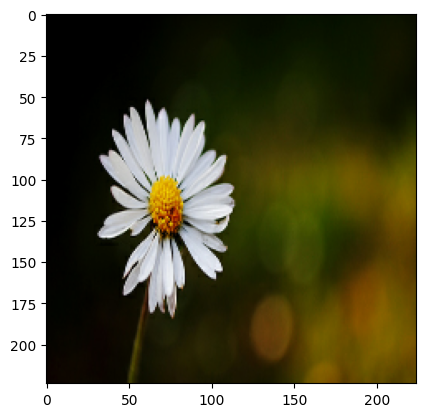

In [101]:
# Iterate and see the pictures and labels
img_batch, labels = next(it)
image = img_batch[0]
plt.imshow(image)
print(labels[0])


Looks like our function is working! :)

In this notebook we have seen how to use shell commands to prepare our data. And defined needed functions which will be used in the second notebook. 

>__Important__: Just to make sure the `image_modeling.py` script is written correctly, you should restart the kernel and run all cells.